In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
min_len = 100
max_len = 200

In [15]:
all_paths = list(Path("/home/wo/bn/dvarapandita/sanskrit-texts/texts").glob("*.txt"))

In [16]:
texts = []

for t in all_paths:
    with open(t) as f:
        try:
            texts.append(f.read())
        except Exception as e:
            texts.append("")
            print(f"{t}: ", e)

/home/wo/bn/dvarapandita/sanskrit-texts/texts/GS41brhatparasarahorasastram.txt:  'utf-8' codec can't decode byte 0xc2 in position 74928: invalid continuation byte


In [17]:
len(texts)

1943

In [18]:
len(list(all_paths))

1943

In [20]:
df = pd.DataFrame({"paths": all_paths, "texts": texts})

In [24]:
df["text_names"] = [p.stem for p in df["paths"]]

In [27]:
def frequency(char, text):
    count = text.count(char)
    if count:
        return  count / len(text)
    else:
        return 0

In [69]:
df["slash_freq"] = [frequency("/", t) for t in df["texts"]]
df["danda_freq"] = [frequency("|", t) for t in df["texts"]]
df["period_freq"] = [frequency(".", t) for t in df["texts"]]
df["comma_freq"] = [frequency(",", t) for t in df["texts"]]

In [71]:
import math

def calculate_std_dev(string_list):
    lengths = [len(s) for s in string_list]  # Step 1

    # Step 2: Calculate mean
    mean_length = sum(lengths) / len(lengths)

    # Step 3: Compute squared differences
    squared_diffs = [(length - mean_length) ** 2 for length in lengths]

    # Step 4: Calculate mean of squared differences
    mean_squared_diff = sum(squared_diffs) / len(squared_diffs)

    # Step 5: Take square root to get standard deviation
    std_dev = math.sqrt(mean_squared_diff)

    return std_dev




In [72]:
df["len_std"] = [calculate_std_dev(t.split('\n')) for t in df["texts"]]

In [88]:
df.sort_values("len_std", ascending=False)[:200]

,paths,texts,text_names,slash_freq,danda_freq,period_freq,comma_freq,len_std
1540,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,<ed_1>\n\n{I}\n\n<śrīgaṇeśāya namaḥ>\n<atha śr...,GSP29muva,0.000750,0.000000,0.000000,0.001528,539.455993
1343,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,"{pratyakṣaparicchedaḥ}\n\n[1,7]\n\tumāpatiṃ sa...",GSP29nyabhu,0.000785,0.000000,0.008393,0.008403,325.257402
1298,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,{(no structure yet)}\n\n<atha vidhivivekaḥ>\n\...,GSP33vidhivi,0.001304,0.016031,0.000000,0.004219,311.606709
318,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,\n\n\n\n\nMuktabodha E-text in UTF-8\n\n\n\n##...,MBksurikopanisatHK,0.000000,0.021364,0.001740,0.002853,240.311445
419,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,\n\n\n\n\nMuktabodha E-text in UTF-8\n\n\n\n##...,MBamrtabinduupanisatHK,0.000000,0.018511,0.001738,0.003275,218.670686
...,...,...,...,...,...,...,...,...
107,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,(Css 238)\n Niraupamyastava\n ... kaṃ bhūtabh...,XXacatstvu,0.015660,0.000000,0.000502,0.000000,38.433131
657,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,Upasenasūtra\nWal_2_1 siddham / rājagṛhe nidān...,K10sf258_sc,0.020825,0.000000,0.000000,0.000000,38.399452
1189,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,aparimitāyuḥ nāma mahāyāna sūtram\nevaṃ mayā ś...,K12n259u,0.000000,0.010316,0.006836,0.006090,38.380250
37,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,mahāprajāpatī gautamī bhagavantam idam avocat ...,K01bhikavau,0.011536,0.000000,0.000047,0.000000,38.369076


In [87]:
for p in df.sort_values("len_std", ascending=False)[:200]["paths"]:
    print (p)

/home/wo/bn/dvarapandita/sanskrit-texts/texts/GSP29muva.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GSP29nyabhu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GSP33vidhivi.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/MBksurikopanisatHK.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/MBamrtabinduupanisatHK.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GSP29vyomavati.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/MBkuladiipikaaHK.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/XXn204u.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GR12sasapa.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/MBamrtanaadopanisatHK.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GSP33brasusau.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/T04tat.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/MBtejobinduupanisatHK.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/T11samtasi.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/MBadvayataarakopanisatHK.txt
/home/wo/bn/dvarapand

In [67]:
df.query('slash_freq <= 0.003 and danda_freq <= 0.005').sort_values("slash_freq")

,paths,texts,text_names,slash_freq,danda_freq
784,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,"09,001.000*0001_01 nārāyaṇaṃ namaskṛtya naraṃ ...",GE07mbh_09_u,0.000000,0.0
1199,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,"Vālmīki: Rāmāyaṇa,\n3. Araṇyakāṇḍa\n3.001.001a...",GE09ram_03_u,0.000000,0.0
1181,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,P1\noṃ namo daśadiganantāparyantalokadhātuprat...,K07sukhvylu,0.000000,0.0
1128,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,,GS41brhatparasarahorasastram,0.000000,0.0
1088,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,"Vālmīki: Rāmāyaṇa,\n5. Sundarakaṇḍa\n5.001.001...",GE09ram_05_u,0.000000,0.0
...,...,...,...,...,...
1329,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,Reconstructed text of the Nagaropamasūtra acc...,XXnagsu_pu,0.002475,0.0
978,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,Reconstructed text of the Nagaropamasūtra acco...,K10nagsu_pu,0.002504,0.0
842,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,"(KauśS_1,1.1) atha vidhiṃ vakṣyāmaḥ\n(KauśS_1,...",GV06kaussu_u,0.002578,0.0
1644,/home/wo/bn/dvarapandita/sanskrit-texts/texts/...,"%Chapter 1: introduction,\n%visualisation of 5...",GSP30timudghu,0.002704,0.0


In [63]:
for p in df.query('slash_freq <= 0.003 and danda_freq <= 0.005').sort_values("slash_freq")[-20:]["paths"]:
    print (p)

/home/wo/bn/dvarapandita/sanskrit-texts/texts/XXsumagavu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/K14sumagavu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GV01rv_08_u.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GV01rv_01_u.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/XXmsudarsu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/K14msudarsu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GSP29snyayvpu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/XXsamyu_wu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/K10samyu_wu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/T11dhksparu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/K01vinv172u.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/GR14kbss_1-u.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/K01vinv171u.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/XXtarkrplu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/T14tarkrplu.txt
/home/wo/bn/dvarapandita/sanskrit-texts/texts/XXnagsu_pu.txt
/home/wo/b

In [4]:
import math

def calculate_std_dev(string_list):
    lengths = [len(s) for s in string_list]  # Step 1

    # Step 2: Calculate mean
    mean_length = sum(lengths) / len(lengths)

    # Step 3: Compute squared differences
    squared_diffs = [(length - mean_length) ** 2 for length in lengths]

    # Step 4: Calculate mean of squared differences
    mean_squared_diff = sum(squared_diffs) / len(squared_diffs)

    # Step 5: Take square root to get standard deviation
    std_dev = math.sqrt(mean_squared_diff)

    return std_dev

# Example usage
string_list = ["apple", "apple", "apple", "apple", "apple"]
std_dev = calculate_std_dev(string_list)
print("Standard deviation of string lengths:", std_dev)

Standard deviation of string lengths: 0.0


In [7]:
with open("/home/wo/bn/dvarapandita/sanskrit-texts/texts/GE07bhg4c02u.txt") as f:
    text = f.read()

In [7]:
sents = text.split("/")

In [ ]:
chunks = []
current_chunk = ""
for s in sents:
    if (current_chunk + s) > 

In [13]:
calculate_std_dev(text.split("/"))

54.37865499515205

In [18]:
text.split("^")

["BhG 1.1\ndhṛtarāṣṭra uvāca\ndharma-kṣetre kuru-kṣetre samavetā yuyutsavaḥ /\nmāmakāḥ pāṇḍavāś caiva kim akurvata saṃjaya //1//\nŚrīdharaḥ -\nśeṣāśeṣa-mukha-vyākhyā-cāturyaṃ tv eka-vaktrataḥ /\ndadhānam adbhutaṃ vande paramānanda-mādhavam //\nśrī-mādhavaṃ praṇamyo mādhavaṃ viśveśam ādarāt /\ntad-bhakti-yantritaḥ kurve gītā-vyākhyāṃ subodhinīm //\nbhāṣya-kāra-mataṃ samyak tad-vyākhyātṛ-giras tathā /\nyathāmati samālocya gītā-vyākhyāṃ samārabhe //\ngītā vyākhyāyate yasyāḥ pāṭha-mātra-prayatnataḥ /\nseyaṃ subodhinī ṭīkā sadā dhyeyā manīṣibhiḥ //\niha khalu sakala-loka-hitāvatāraḥ parama-kāruṇiko bhagavān devakī-nandanas tattvājñāna-vijṛmbhita-śoka-moha-bhraṃśita-vivekatayā\nnija-dharma-parityāga-pūrvaka-para-dharmābhisandhinam arjunaṃ dharma-jñāna-rahasyopadeśa-plavena\ntasmāc choka-moha-sāgarād uddadhāra /\ntam eva bhagavad-upadiṣṭam arthaṃ kṛṣṇa-dvaipāyanaḥ saptabhiḥ śloka-śatair upanibabandha /\ntatra ca prāyaśaḥ śrī-kṛṣṇa-mukhād viniḥsṛtān eva ślokān alikhat /\nkāṃścit tat-saṅgataye 

In [8]:
len(text.split("^"))

3

In [9]:
calculate_std_dev(text.split("^"))


92231.00090533552

In [18]:
def frequency(char, text):
    count = text.count(char)
    if count:
        return  count / len(text)
    else:
        return 0

In [51]:
def freq_hist(char):
    slash_fr = []
    for t in texts:
        slash_fr.append(frequency(char, t))
    slash_fr = [i for i in slash_fr if i != 0]
    plt.hist(slash_fr, bins=100, alpha=0.5)
    plt.title('Random Gaussian data (fixed bin size)')
    plt.xlabel('variable X (bin size = 5)')
    plt.ylabel('count')

    plt.show()

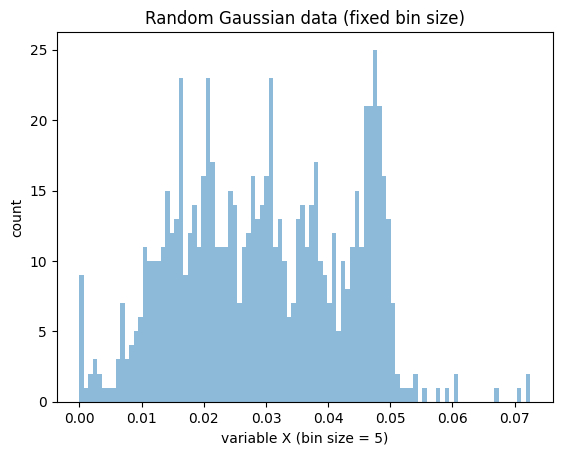

In [52]:
freq_hist("|")

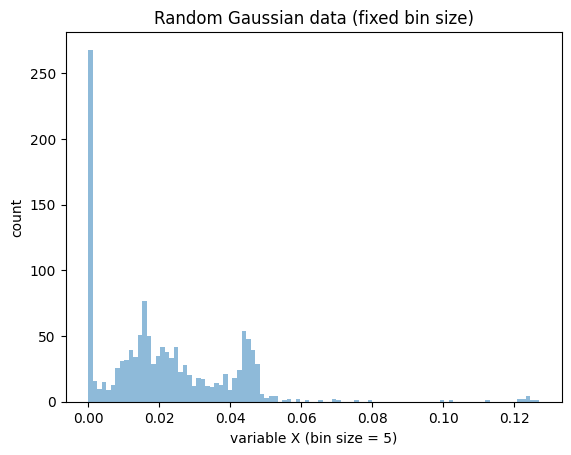

In [53]:
freq_hist("/")